<a href="https://colab.research.google.com/github/irfanali11/sensor-fusion-robustness-study/blob/main/sensor_fusion_robustness_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision opencv-python scipy numpy matplotlib scikit-learn -q

In [2]:
!wget "http://www.utdallas.edu/~kehtar/UTD-MAD/RGB.zip" -O rgb.zip
!wget "http://www.utdallas.edu/~kehtar/UTD-MAD/Inertial.zip" -O inertial.zip

!mkdir -p data/rgb data/inertial
!unzip -q rgb.zip -d data/rgb
!unzip -q inertial.zip -d data/inertial

!ls data/rgb | head -5
!ls data/inertial | head -5

--2026-09-07 20:54:48--  http://www.utdallas.edu/~kehtar/UTD-MAD/RGB.zip
Resolving www.utdallas.edu (www.utdallas.edu)... 3.133.32.155, 3.21.250.42
Connecting to www.utdallas.edu (www.utdallas.edu)|3.133.32.155|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.utdallas.edu/~kehtar/UTD-MAD/RGB.zip [following]
--2026-09-07 20:54:48--  https://www.utdallas.edu/~kehtar/UTD-MAD/RGB.zip
Connecting to www.utdallas.edu (www.utdallas.edu)|3.133.32.155|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://personal.utdallas.edu/~kehtar/UTD-MAD/RGB.zip [following]
--2026-09-07 20:54:49--  https://personal.utdallas.edu/~kehtar/UTD-MAD/RGB.zip
Resolving personal.utdallas.edu (personal.utdallas.edu)... 129.110.46.112
Connecting to personal.utdallas.edu (personal.utdallas.edu)|129.110.46.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1106885499 (1.0G) [application/zip]
Saving to: ‘rgb.zi

In [3]:
!ls data/rgb/RGB | head -5
!ls data/inertial/Inertial | head -5

a10_s1_t1_color.avi
a10_s1_t2_color.avi
a10_s1_t3_color.avi
a10_s1_t4_color.avi
a10_s2_t1_color.avi
a10_s1_t1_inertial.mat
a10_s1_t2_inertial.mat
a10_s1_t3_inertial.mat
a10_s1_t4_inertial.mat
a10_s2_t1_inertial.mat


In [4]:
!ls data/rgb/RGB | wc -l
!ls data/inertial/Inertial | wc -l

861
861


In [5]:
import os
import cv2
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
def load_video_frames(video_path, num_frames=16, resize=(112, 112)):
    """Load a fixed number of evenly-spaced frames from a video, resized."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((num_frames, *resize, 3), dtype=np.float32)

    idxs = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    idx_set = set(idxs.tolist())
    current = 0
    grabbed = {}
    while cap.isOpened() and len(grabbed) < len(idx_set):
        ret, frame = cap.read()
        if not ret:
            break
        if current in idx_set:
            frame = cv2.resize(frame, resize)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            grabbed[current] = frame
        current += 1
    cap.release()

    frames = [grabbed.get(i, np.zeros((*resize, 3), dtype=np.float32)) for i in idxs]
    return np.stack(frames, axis=0)  # (num_frames, H, W, 3)


def load_inertial(mat_path, seq_len=100):
    """Load IMU data from .mat file, pad/truncate to fixed sequence length."""
    mat = sio.loadmat(mat_path)
    data = mat["d_iner"].astype(np.float32)  # shape (T, 6): accel(3)+gyro(3)
    if data.shape[0] >= seq_len:
        data = data[:seq_len]
    else:
        pad = np.zeros((seq_len - data.shape[0], data.shape[1]), dtype=np.float32)
        data = np.concatenate([data, pad], axis=0)
    return data  # (seq_len, 6)


def parse_action_label(filename):
    """'a1_s2_t3_color.avi' -> action label 0 (zero-indexed)."""
    base = os.path.basename(filename)
    action_str = base.split("_")[0]  # 'a1'
    return int(action_str.replace("a", "")) - 1

In [7]:
class UTDMHADDataset(Dataset):
    def __init__(self, rgb_dir, inertial_dir, num_frames=16, seq_len=100,
                 corruption_fn=None):
        self.rgb_dir = rgb_dir
        self.inertial_dir = inertial_dir
        self.num_frames = num_frames
        self.seq_len = seq_len
        self.corruption_fn = corruption_fn

        self.samples = []
        for fname in sorted(os.listdir(rgb_dir)):
            if not fname.endswith("_color.avi"):
                continue
            base_id = fname.replace("_color.avi", "")
            inertial_fname = base_id + "_inertial.mat"
            inertial_path = os.path.join(inertial_dir, inertial_fname)
            if os.path.exists(inertial_path):
                self.samples.append((
                    os.path.join(rgb_dir, fname),
                    inertial_path,
                    parse_action_label(fname)
                ))

        print(f"Found {len(self.samples)} paired video+IMU samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, imu_path, label = self.samples[idx]
        video = load_video_frames(video_path, self.num_frames)
        imu = load_inertial(imu_path, self.seq_len)

        if self.corruption_fn is not None:
            video, imu = self.corruption_fn(video, imu)

        video = torch.from_numpy(video).permute(0, 3, 1, 2).float()  # (T,3,H,W)
        imu = torch.from_numpy(imu).float()                           # (seq_len,6)
        return video, imu, label


def get_dataloaders(rgb_dir, inertial_dir, batch_size=8, corruption_fn=None):
    full_dataset = UTDMHADDataset(rgb_dir, inertial_dir, corruption_fn=corruption_fn)
    n = len(full_dataset)
    idxs = list(range(n))
    train_idx, test_idx = train_test_split(idxs, test_size=0.2, random_state=42)

    train_set = torch.utils.data.Subset(full_dataset, train_idx)
    test_set = torch.utils.data.Subset(full_dataset, test_idx)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [8]:
class VisionBranch(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feat = self.cnn(x).view(B * T, -1)
        feat = self.fc(feat)
        feat = feat.view(B, T, -1).mean(dim=1)
        return feat

In [9]:
class IMUBranch(nn.Module):
    def __init__(self, in_channels=6, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(32, out_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B,6,seq_len)
        feat = self.net(x).squeeze(-1)
        return self.fc(feat)

In [10]:
import torch.nn as nn

class EarlyFusionModel(nn.Module):
    def __init__(self, num_classes=27, vision_dim=64, imu_dim=32):
        super().__init__()
        self.vision = VisionBranch(vision_dim)
        self.imu = IMUBranch(out_dim=imu_dim)
        self.classifier = nn.Sequential(
            nn.Linear(vision_dim + imu_dim, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, video, imu):
        v_feat = self.vision(video)
        i_feat = self.imu(imu)
        combined = torch.cat([v_feat, i_feat], dim=1)
        return self.classifier(combined)

In [11]:
import torch.nn as nn

class EarlyFusionModel(nn.Module):
    def __init__(self, num_classes=27, vision_dim=64, imu_dim=32):
        super().__init__()
        self.vision = VisionBranch(vision_dim)
        self.imu = IMUBranch(out_dim=imu_dim)
        self.classifier = nn.Sequential(
            nn.Linear(vision_dim + imu_dim, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, video, imu):
        v_feat = self.vision(video)
        i_feat = self.imu(imu)
        combined = torch.cat([v_feat, i_feat], dim=1)
        return self.classifier(combined)

In [12]:
class LateFusionModel(nn.Module):
    def __init__(self, num_classes=27, vision_dim=64, imu_dim=32):
        super().__init__()
        self.vision = VisionBranch(vision_dim)
        self.imu = IMUBranch(out_dim=imu_dim)
        self.vision_head = nn.Linear(vision_dim, num_classes)
        self.imu_head = nn.Linear(imu_dim, num_classes)

    def forward(self, video, imu):
        v_logits = self.vision_head(self.vision(video))
        i_logits = self.imu_head(self.imu(imu))
        return (v_logits + i_logits) / 2.0

In [14]:
def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for video, imu, label in train_loader:
            video, imu, label = video.to(device), imu.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(video, imu)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        acc = evaluate_model(model, test_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

    return model


def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for video, imu, label in loader:
            video, imu, label = video.to(device), imu.to(device), label.to(device)
            logits = model(video, imu)
            preds = logits.argmax(dim=1)
            correct += (preds == label).sum().item()
            total += label.size(0)
    return correct / total

In [15]:
!ls data/rgb/RGB | wc -l

861


In [16]:
print(device)

cuda


In [17]:
print(EarlyFusionModel)
print(LateFusionModel)
print(train_model)
print(get_dataloaders)

<class '__main__.EarlyFusionModel'>
<class '__main__.LateFusionModel'>
<function train_model at 0x799b5a2f3240>
<function get_dataloaders at 0x799b5a2f2980>


In [18]:
RGB_DIR = "data/rgb/RGB"
INERTIAL_DIR = "data/inertial/Inertial"

train_loader, test_loader = get_dataloaders(RGB_DIR, INERTIAL_DIR, batch_size=8)

early_model = EarlyFusionModel()
early_model = train_model(early_model, train_loader, test_loader, epochs=15)

late_model = LateFusionModel()
late_model = train_model(late_model, train_loader, test_loader, epochs=15)

baseline_early_acc = evaluate_model(early_model, test_loader)
baseline_late_acc = evaluate_model(late_model, test_loader)
print("Baseline - Early fusion:", baseline_early_acc, "| Late fusion:", baseline_late_acc)

Found 861 paired video+IMU samples.
Epoch 1/15 | Loss: 2.9617 | Test Acc: 0.3179
Epoch 2/15 | Loss: 1.8994 | Test Acc: 0.4335
Epoch 3/15 | Loss: 1.4812 | Test Acc: 0.5896
Epoch 4/15 | Loss: 1.1549 | Test Acc: 0.6301
Epoch 5/15 | Loss: 0.9919 | Test Acc: 0.5954
Epoch 6/15 | Loss: 0.8688 | Test Acc: 0.5838
Epoch 7/15 | Loss: 0.7261 | Test Acc: 0.6647
Epoch 8/15 | Loss: 0.6863 | Test Acc: 0.6763
Epoch 9/15 | Loss: 0.5524 | Test Acc: 0.6994
Epoch 10/15 | Loss: 0.5408 | Test Acc: 0.7110
Epoch 11/15 | Loss: 0.5472 | Test Acc: 0.6763
Epoch 12/15 | Loss: 0.5359 | Test Acc: 0.7457
Epoch 13/15 | Loss: 0.4643 | Test Acc: 0.7514
Epoch 14/15 | Loss: 0.3570 | Test Acc: 0.7341
Epoch 15/15 | Loss: 0.3462 | Test Acc: 0.7572
Epoch 1/15 | Loss: 3.0000 | Test Acc: 0.2197
Epoch 2/15 | Loss: 2.0691 | Test Acc: 0.3988
Epoch 3/15 | Loss: 1.5713 | Test Acc: 0.4913
Epoch 4/15 | Loss: 1.2528 | Test Acc: 0.5491
Epoch 5/15 | Loss: 1.1122 | Test Acc: 0.6647
Epoch 6/15 | Loss: 0.9599 | Test Acc: 0.6474
Epoch 7/15 | 

In [24]:
def random_frame_drop(video, imu, drop_prob=0.3):
    video = video.copy()
    T = video.shape[0]
    mask = np.random.rand(T) < drop_prob
    video[mask] = 0.0
    return video, imu


def block_occlusion(video, imu, block_frac=0.3):
    video = video.copy()
    T = video.shape[0]
    block_len = int(T * block_frac)
    if block_len == 0:
        return video, imu
    start = np.random.randint(0, T - block_len + 1)
    video[start:start + block_len] = 0.0
    return video, imu


def imu_noise(video, imu, noise_std=0.5):
    imu = imu.copy()
    imu += np.random.normal(0, noise_std, imu.shape).astype(np.float32)
    return video, imu


def make_corruption_fn(kind, severity):
    if kind == "frame_drop":
        return lambda v, i: random_frame_drop(v, i, drop_prob=severity)
    elif kind == "block_occlusion":
        return lambda v, i: block_occlusion(v, i, block_frac=severity)
    elif kind == "imu_noise":
        return lambda v, i: imu_noise(v, i, noise_std=severity)
    else:
        raise ValueError(f"Unknown corruption kind: {kind}")

In [20]:
results = {"early": {}, "late": {}}
severities = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
corruption_kinds = ["frame_drop", "block_occlusion", "imu_noise"]

for kind in corruption_kinds:
    results["early"][kind] = []
    results["late"][kind] = []
    for sev in severities:
        corruption_fn = make_corruption_fn(kind, sev) if sev > 0 else None
        _, corrupted_test_loader = get_dataloaders(
            RGB_DIR, INERTIAL_DIR, batch_size=8, corruption_fn=corruption_fn
        )
        acc_early = evaluate_model(early_model, corrupted_test_loader)
        acc_late = evaluate_model(late_model, corrupted_test_loader)
        results["early"][kind].append(acc_early)
        results["late"][kind].append(acc_late)
        print(f"{kind} severity={sev}: early={acc_early:.3f}, late={acc_late:.3f}")

Found 861 paired video+IMU samples.
frame_drop severity=0.0: early=0.757, late=0.821
Found 861 paired video+IMU samples.
frame_drop severity=0.1: early=0.763, late=0.832
Found 861 paired video+IMU samples.
frame_drop severity=0.2: early=0.757, late=0.792
Found 861 paired video+IMU samples.
frame_drop severity=0.3: early=0.757, late=0.751
Found 861 paired video+IMU samples.
frame_drop severity=0.4: early=0.769, late=0.734
Found 861 paired video+IMU samples.
frame_drop severity=0.5: early=0.723, late=0.688
Found 861 paired video+IMU samples.
block_occlusion severity=0.0: early=0.757, late=0.821
Found 861 paired video+IMU samples.
block_occlusion severity=0.1: early=0.757, late=0.832
Found 861 paired video+IMU samples.
block_occlusion severity=0.2: early=0.769, late=0.798
Found 861 paired video+IMU samples.
block_occlusion severity=0.3: early=0.769, late=0.775
Found 861 paired video+IMU samples.
block_occlusion severity=0.4: early=0.746, late=0.740
Found 861 paired video+IMU samples.
bloc

In [21]:
torch.save(early_model.state_dict(), "early_model.pth")
torch.save(late_model.state_dict(), "late_model.pth")
print("Models saved.")

Models saved.


In [22]:
sample_video, sample_imu, sample_label = train_loader.dataset[0]
print("IMU data range:", sample_imu.min().item(), "to", sample_imu.max().item())
print("IMU data std:", sample_imu.std().item())

IMU data range: -269.89312744140625 to 155.14503479003906
IMU data std: 60.13425064086914


In [23]:
train_loader, test_loader = get_dataloaders(RGB_DIR, INERTIAL_DIR, batch_size=8)

sample_video, sample_imu, sample_label = train_loader.dataset[0]
print("IMU data range:", sample_imu.min().item(), "to", sample_imu.max().item())
print("IMU data std:", sample_imu.std().item())

Found 861 paired video+IMU samples.
IMU data range: -269.89312744140625 to 155.14503479003906
IMU data std: 60.13425064086914


In [26]:
def imu_noise(video, imu, noise_std=0.5):
    imu = imu.copy()
    real_scale = imu.std() if imu.std() > 0 else 1.0
    imu += np.random.normal(0, noise_std * real_scale, imu.shape).astype(np.float32)
    return video, imu

In [27]:
results["early"]["imu_noise"] = []
results["late"]["imu_noise"] = []
for sev in severities:
    corruption_fn = make_corruption_fn("imu_noise", sev) if sev > 0 else None
    _, corrupted_test_loader = get_dataloaders(
        RGB_DIR, INERTIAL_DIR, batch_size=8, corruption_fn=corruption_fn
    )
    acc_early = evaluate_model(early_model, corrupted_test_loader)
    acc_late = evaluate_model(late_model, corrupted_test_loader)
    results["early"]["imu_noise"].append(acc_early)
    results["late"]["imu_noise"].append(acc_late)
    print(f"imu_noise severity={sev}: early={acc_early:.3f}, late={acc_late:.3f}")

Found 861 paired video+IMU samples.
imu_noise severity=0.0: early=0.757, late=0.821
Found 861 paired video+IMU samples.
imu_noise severity=0.1: early=0.757, late=0.815
Found 861 paired video+IMU samples.
imu_noise severity=0.2: early=0.763, late=0.751
Found 861 paired video+IMU samples.
imu_noise severity=0.3: early=0.751, late=0.734
Found 861 paired video+IMU samples.
imu_noise severity=0.4: early=0.746, late=0.659
Found 861 paired video+IMU samples.
imu_noise severity=0.5: early=0.682, late=0.526


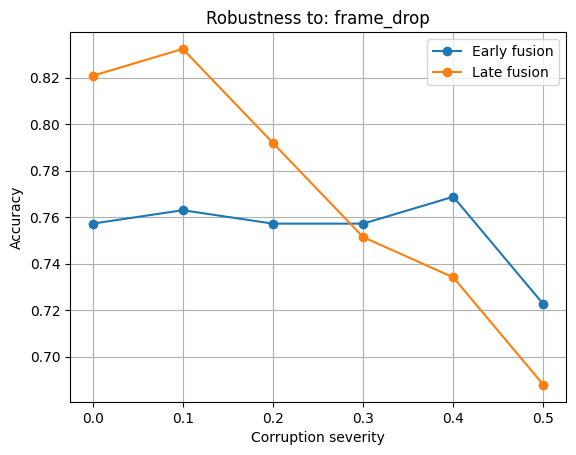

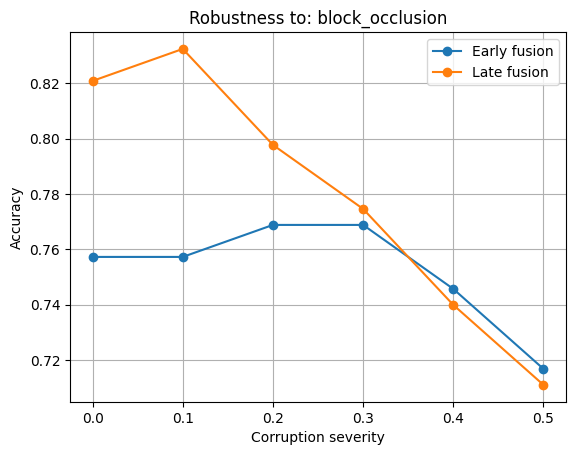

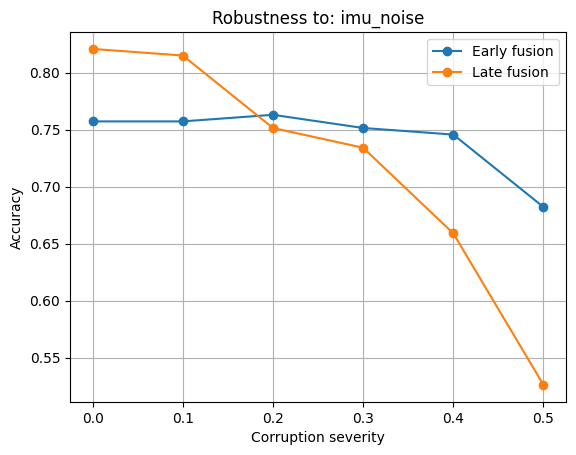

In [28]:
for kind in corruption_kinds:
    plt.figure()
    plt.plot(severities, results["early"][kind], marker='o', label="Early fusion")
    plt.plot(severities, results["late"][kind], marker='o', label="Late fusion")
    plt.xlabel("Corruption severity")
    plt.ylabel("Accuracy")
    plt.title(f"Robustness to: {kind}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"robustness_{kind}.png")
    plt.show()

In [30]:
torch.save(early_model.state_dict(), "early_model.pth")
torch.save(late_model.state_dict(), "late_model.pth")
print("Models saved.")

Models saved.


In [31]:
!ls *.png

robustness_block_occlusion.png	robustness_imu_noise.png
robustness_frame_drop.png
